# KMeans - Credit Card Customer Segmentation

**Algorithm:** K-Means Clustering  
**Dataset:** CC GENERAL (8,950 credit card users)  
**Task:** Segment customers into groups based on spending behavior

In [1]:
# Google Colab setup - mount Drive if in Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/AI PROJECT DATASET/
    print('Running in Colab - Drive mounted')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
%matplotlib inline

In [3]:
df = pd.read_csv('CC GENERAL.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [5]:
# Check for missing values
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [6]:
# Handle missing values
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# Drop customer ID for clustering
X = df.drop(columns=['CUST_ID'])
print(f'Features: {list(X.columns)}')

Features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [7]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

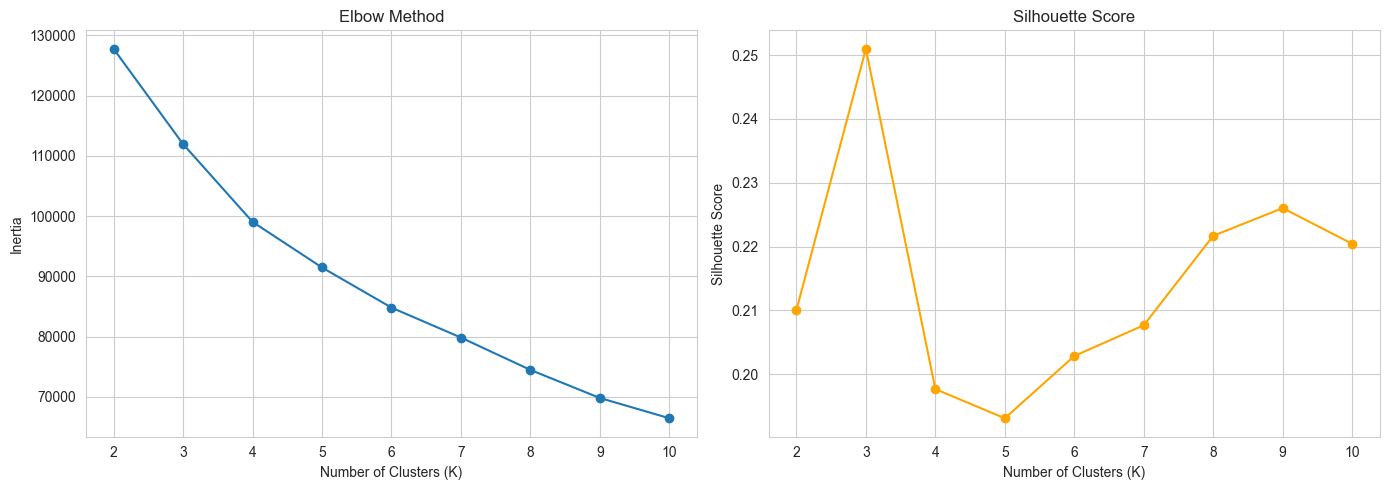

In [8]:
# Elbow Method to find optimal K
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

ax1.plot(K_range, inertias, marker='o')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouettes, marker='o', color='orange')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

In [9]:
# Apply KMeans with optimal K (let's use 4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Silhouette Score (K={optimal_k}): {silhouette_score(X_scaled, df["Cluster"]):.4f}')

Silhouette Score (K=4): 0.1977


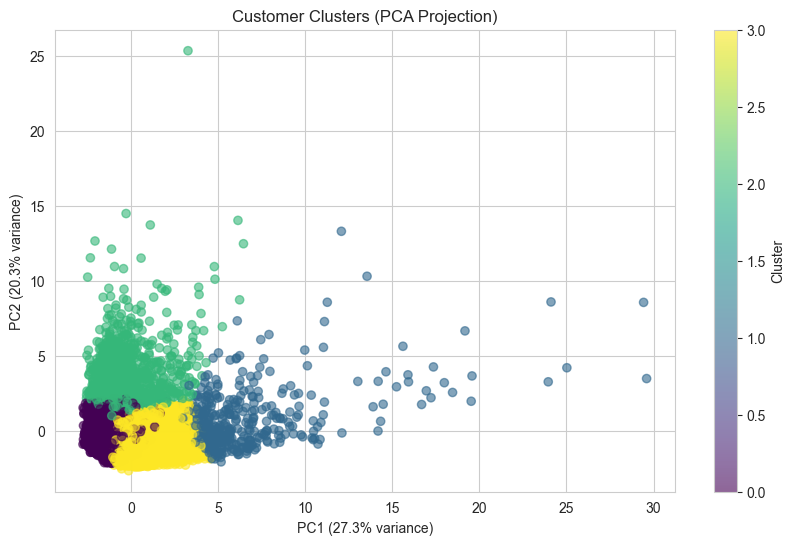

In [10]:
# PCA for visualization (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Clusters (PCA Projection)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.show()

In [11]:
# Analyze cluster characteristics
assert 'Cluster' in df.columns, 'Run KMeans cell first!'

cluster_profile = df.drop(columns=['CUST_ID']).groupby('Cluster').mean()
cluster_profile


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.640516,974.260054,553.900449,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1972.767288,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2003.674460,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,639.677258,0.269258,11.594595


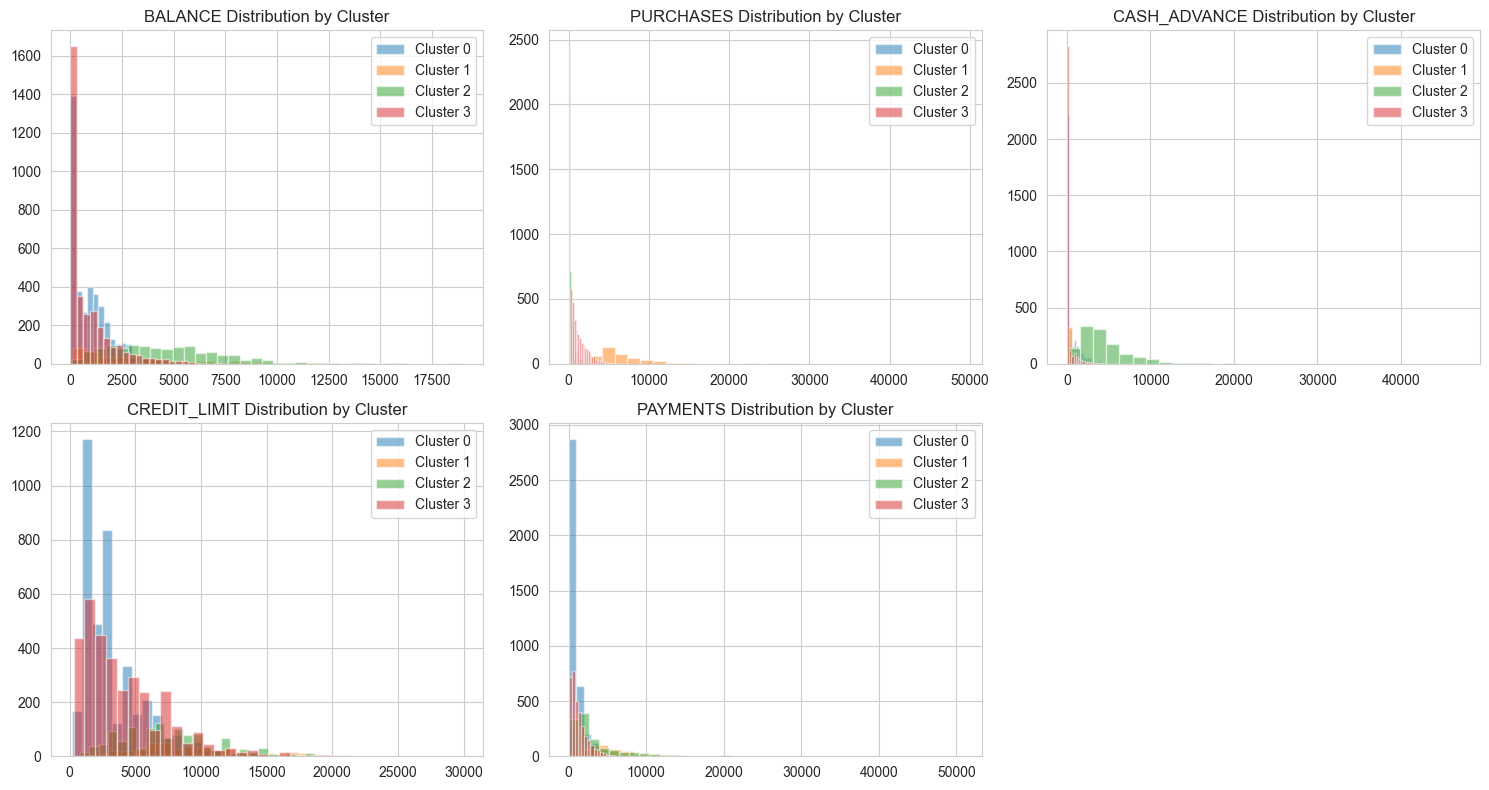

In [12]:
# Visualize key features across clusters
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for cluster in range(optimal_k):
        data = df[df['Cluster'] == cluster][feat]
        axes[i].hist(data, bins=30, alpha=0.5, label=f'Cluster {cluster}')
    axes[i].set_title(f'{feat} Distribution by Cluster')
    axes[i].legend()

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [13]:
# Cluster interpretation with names
# Adjust these names based on actual cluster means from the profile above
cluster_names = {
    0: 'High Spenders',
    1: 'Cash Advance Users',
    2: 'Low Activity',
    3: 'Revolvers (Installment Buyers)'
}
df['Segment'] = df['Cluster'].map(cluster_names)

for cluster in range(optimal_k):
    size = (df['Cluster'] == cluster).sum()
    name = cluster_names[cluster]
    bal = cluster_profile.loc[cluster, 'BALANCE']
    pur = cluster_profile.loc[cluster, 'PURCHASES']
    ca = cluster_profile.loc[cluster, 'CASH_ADVANCE']
    cl = cluster_profile.loc[cluster, 'CREDIT_LIMIT']
    print(f'Cluster {cluster} - {name}: {size} customers')
    print(f'  Balance: ${bal:.0f}, Purchases: ${pur:.0f}, Cash Advance: ${ca:.0f}, Credit Limit: ${cl:.0f}')
    print()


Cluster 0 - High Spenders: 3977 customers
  Balance: $1013, Purchases: $270, Cash Advance: $597, Credit Limit: $3279

Cluster 1 - Cash Advance Users: 409 customers
  Balance: $3551, Purchases: $7682, Cash Advance: $654, Credit Limit: $9697

Cluster 2 - Low Activity: 1197 customers
  Balance: $4602, Purchases: $502, Cash Advance: $4522, Credit Limit: $7546

Cluster 3 - Revolvers (Installment Buyers): 3367 customers
  Balance: $895, Purchases: $1236, Cash Advance: $211, Credit Limit: $4213



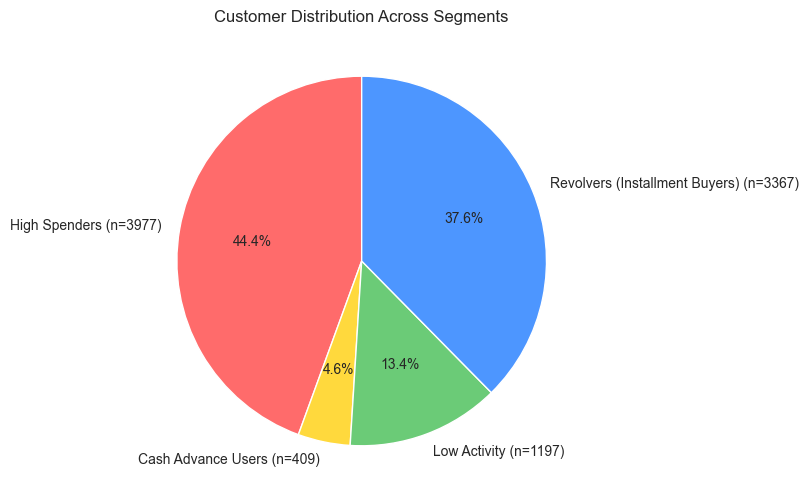

In [14]:
# Cluster size pie chart
cluster_counts = df['Cluster'].value_counts().sort_index()
cluster_labels = [f'{cluster_names.get(c, c)} (n={cluster_counts[c]})' for c in cluster_counts.index]

plt.figure(figsize=(8, 6))
plt.pie(cluster_counts, labels=cluster_labels, autopct='%1.1f%%', startangle=90, colors=['#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff'])
plt.title('Customer Distribution Across Segments')
plt.show()


### Conclusion
KMeans successfully segments credit card customers into distinct behavioral groups. Each cluster represents a different customer profile (e.g., big spenders, cash-heavy users, low-activity users), enabling targeted marketing strategies.